# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import tree
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from matplotlib.pyplot import clf
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [21]:
#seu código aqui
X_train_balanced = pd.read_csv('X_train_balanced.csv', delimiter=',')
X_test = pd.read_csv('X_test.csv', delimiter=',')
y_train_balanced = pd.read_csv('y_train_balanced.csv', delimiter=',')
y_test = pd.read_csv('y_test.csv', delimiter=',')

In [22]:
X_test = pd.get_dummies(X_test)
X_test = X_test.reindex(columns=X_train_balanced.columns, fill_value=0)

In [23]:
X_train_balanced

,Age,Number of Children,Gender_Male,"Income_105.000,00","Income_110.000,00","Income_112.500,00","Income_115.000,00","Income_117.500,00","Income_120.000,00","Income_122.500,00",...,"Income_90.000,00","Income_92.500,00","Income_95.000,00","Income_97.500,00",Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital Status_Single,Home Ownership_Rented
0,36.000000,2,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,33.000000,0,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,True
2,40.000000,0,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
3,43.000000,0,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,True,False
4,49.000000,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,27.000000,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,True
197,27.460159,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,True
198,27.796939,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,True
199,28.000000,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True


In [24]:
X_test

,Age,Number of Children,Gender_Male,"Income_105.000,00","Income_110.000,00","Income_112.500,00","Income_115.000,00","Income_117.500,00","Income_120.000,00","Income_122.500,00",...,"Income_90.000,00","Income_92.500,00","Income_95.000,00","Income_97.500,00",Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital Status_Single,Home Ownership_Rented
0,31.0,0,True,0,0,0,False,False,0,0,...,False,0,False,False,True,False,False,False,True,True
1,29.0,0,False,0,0,0,False,False,0,0,...,False,0,False,False,False,False,True,False,True,True
2,40.0,0,True,0,0,0,False,False,0,0,...,False,0,False,False,False,False,True,False,True,False
3,42.0,0,True,0,0,0,False,False,0,0,...,False,0,False,False,False,False,False,True,True,False
4,50.0,0,True,0,0,0,False,False,0,0,...,False,0,False,False,False,False,False,True,False,False
5,36.0,2,False,0,0,0,False,False,0,0,...,True,0,False,False,False,False,False,True,False,False
6,30.0,2,True,0,0,0,False,True,0,0,...,False,0,False,False,False,False,False,True,False,False
7,31.0,0,True,0,0,0,False,False,0,0,...,False,0,True,False,False,True,False,False,True,True
8,32.0,0,True,0,0,0,False,False,0,0,...,False,0,False,False,False,False,False,False,True,True
9,46.0,1,False,0,0,0,False,False,0,0,...,False,0,True,False,False,False,True,False,False,False


In [25]:
y_train_balanced

,Credit Score
0,High
1,Average
2,High
3,High
4,High
...,...
196,Low
197,Low
198,Low
199,Low


In [26]:
y_test

,Credit Score
0,Average
1,Low
2,High
3,High
4,High
5,High
6,High
7,High
8,Average
9,High


In [27]:
train_balance = y_train_balanced.value_counts()
print('Balanceamento de y train:')
print(train_balance)

test_balance = y_test.value_counts()
print('\nBalanceamento de y test:')
print(test_balance)

Balanceamento de y train:
Credit Score
High            67
Average         67
Low             67
Name: count, dtype: int64

Balanceamento de y test:
Credit Score
High            21
Average          9
Low              3
Name: count, dtype: int64


# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

Pré-processamento dos dados: Inicialmente, realizei a verificação do balanceamento das classes da variável target para evitar viés do modelo e garantir uma distribuição mais uniforme entre as categorias. Transformei as variáveis categóricas (como income e education) em variáveis dummies por meio da técnica de one-hot encoding, permitindo que o modelo trabalhe corretamente com os dados. Conferi também a se existia velores ausentes e tratei deles removendo porque no caso seriam poucos dados que não fariam diferença no conjunto.

Separação dos conjuntos de treino e teste: Utilizei o conjunto de dados já balanceado para dividir em conjuntos de treino (X_train_balanced, y_train_balanced) e teste (X_test, y_test). Esta separação é importante para avaliar o desempenho real do modelo, evitando vazamento de dados e permitindo validar o que foi aprendido.

Aplicação do modelo de Árvore de Decisão: Implementei o classificador DecisionTreeClassifier do scikit-learn, utilizando o critério "gini" e random_state=0 para garantir reprodutibilidade. O modelo foi treinado usando o conjunto de treino.

Avaliação e comparação dos resultados: Para respeitar o padrão do one-hot encoding, foram usadas todas as colunas associadas às duas variáveis principais ("Income" e "Home Ownership"), e que a ausência de algumas categorias pode estar ligada ao padrão dos dados ou à configuração do get_dummies após isso, avaliei o desempenho do modelo no conjunto teste utilizando métricas como acurácia, precisão, recall e f1-score. Também comparei os resultados do treino e do teste para verificar possíveis sinais de overfitting. E também fiz uma análise sobre os resultados comparando com os resultados do naive bayes que foi treinado no módulo passado.

In [28]:
#Sua resposta aqui

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [29]:
#seu código aqui
clf = DecisionTreeClassifier (criterion='gini', random_state=0)
clf.fit(X_train_balanced, y_train_balanced)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [30]:
#seu código aqui
previsoes = clf.predict(X_test)
acuracia = accuracy_score(y_test, previsoes)
print("Acurácia:", acuracia)

Acurácia: 0.9090909090909091


In [31]:
relatorio = classification_report(y_test, previsoes)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

     Average       0.75      1.00      0.86         9
        High       1.00      0.90      0.95        21
         Low       1.00      0.67      0.80         3

    accuracy                           0.91        33
   macro avg       0.92      0.86      0.87        33
weighted avg       0.93      0.91      0.91        33



# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

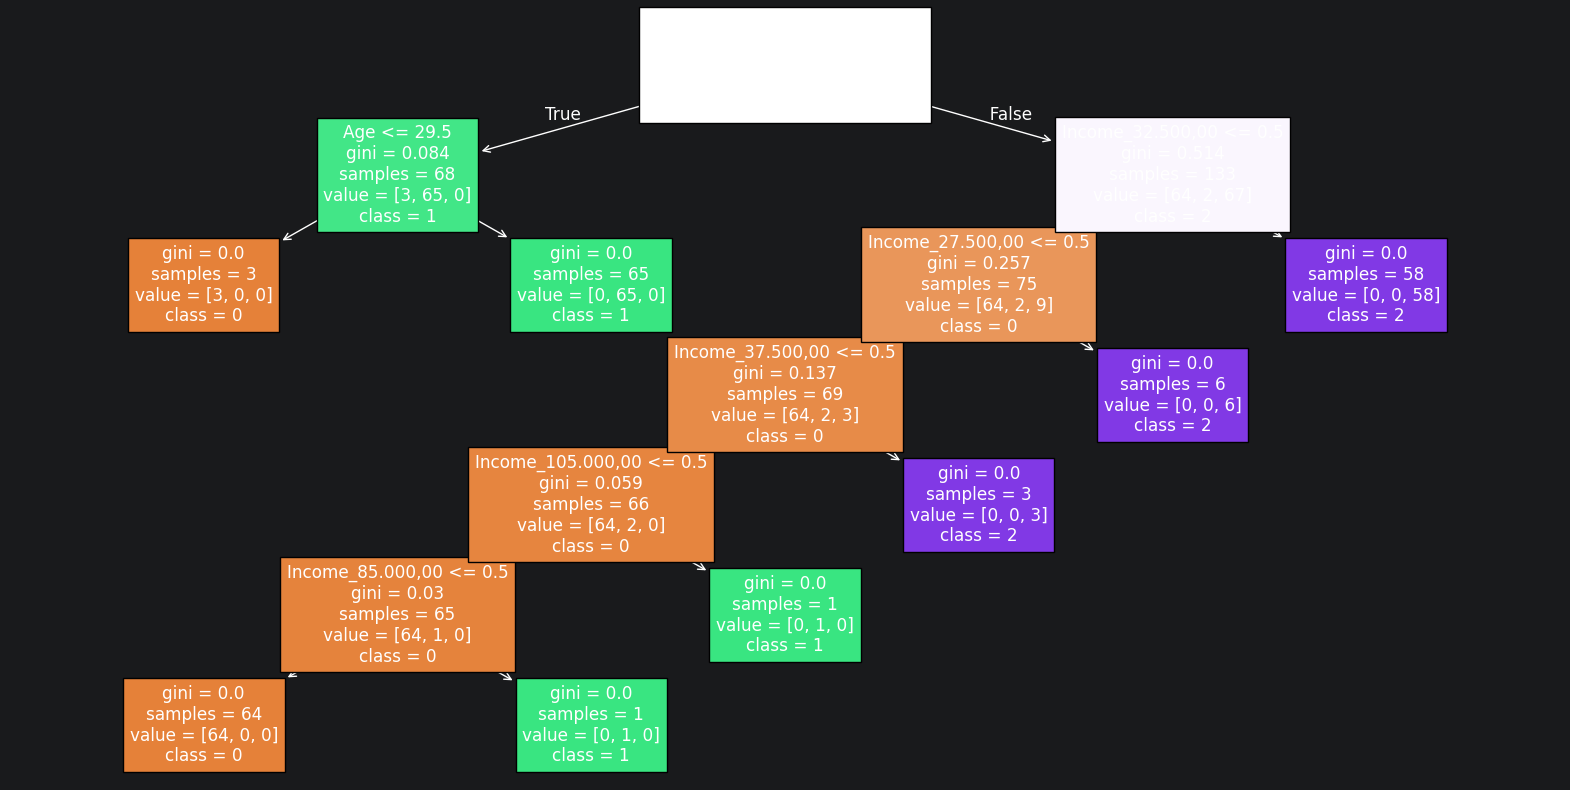

In [32]:
#seu código aqui
plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=X_train_balanced.columns, class_names=['0', '1', '2'])
plt.show()

# 6) Identifique as 2 principais features do modelo.


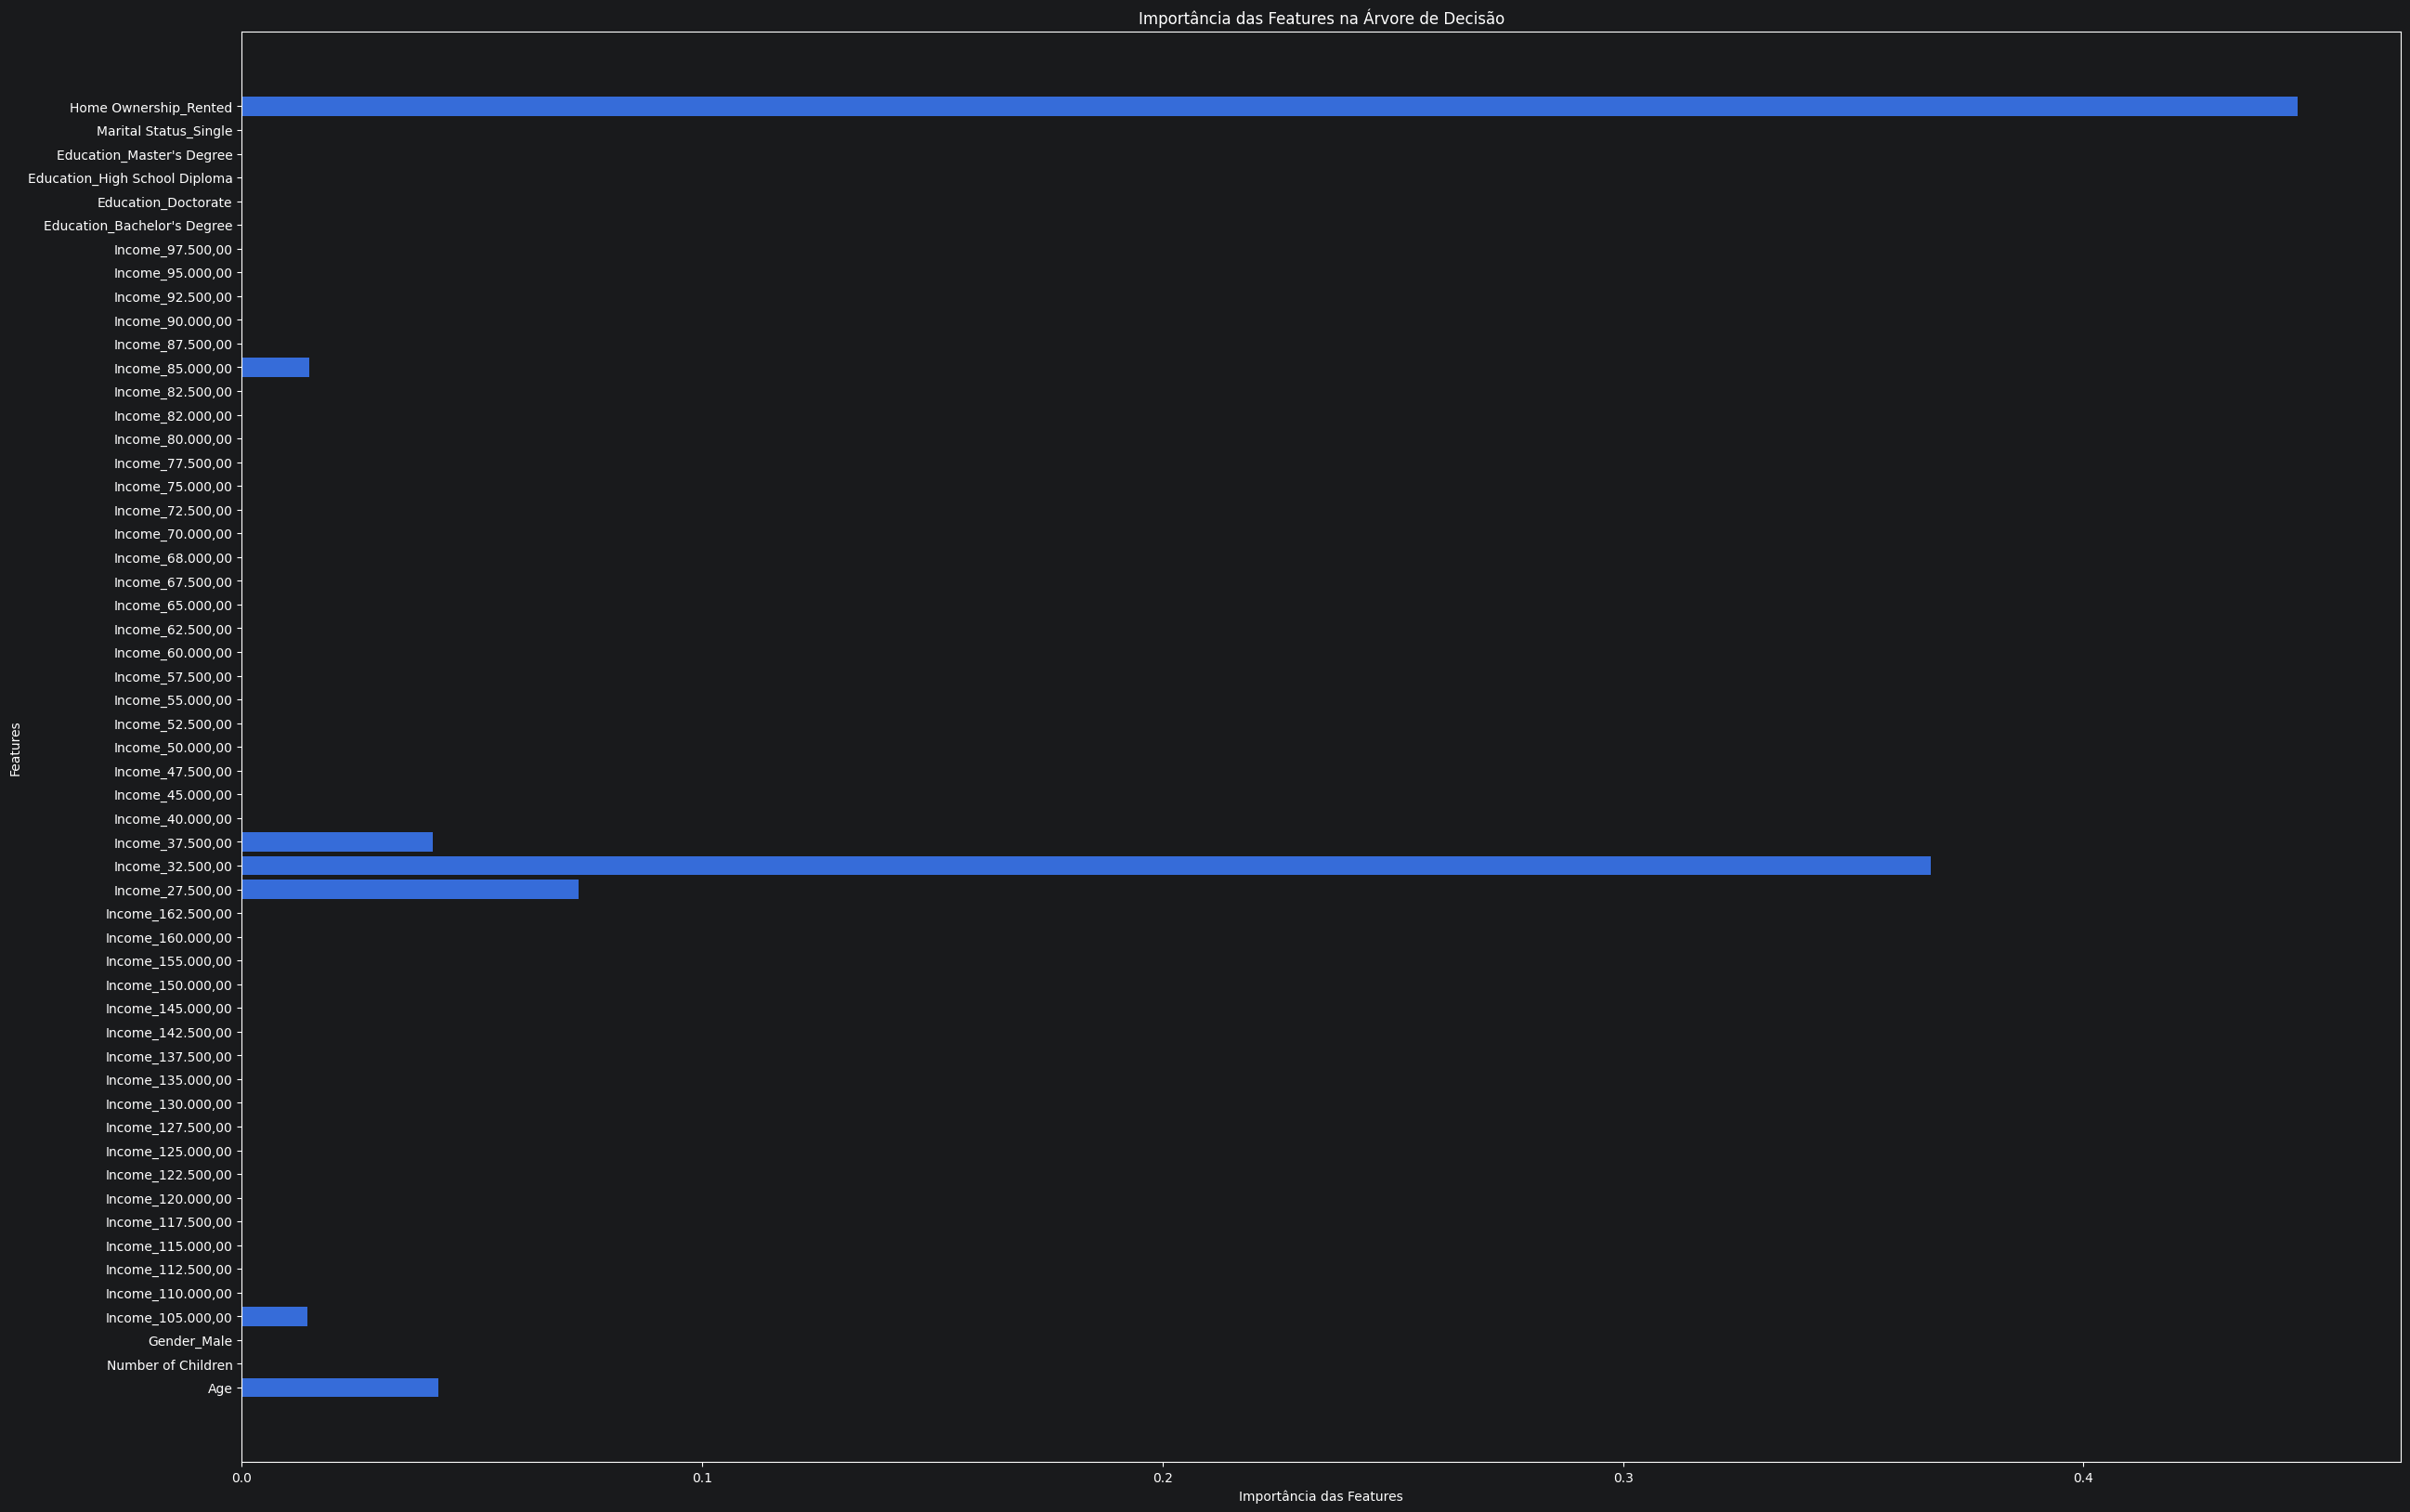

In [33]:
#seu código aqui
importancias_features = clf.feature_importances_
nomes_features = X_train_balanced.columns

plt.figure(figsize=(30, 20))
plt.barh(nomes_features, importancias_features)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [34]:
#seu código aqui
home_cols = [col for col in X_train_balanced.columns if "Home Ownership" in col]
income_cols = [col for col in X_train_balanced.columns if "Income" in col]
features_principais = home_cols + income_cols

X_train_reduzido = X_train_balanced[features_principais]
X_test_reduzido = X_test[features_principais]

In [35]:
clf_reduzido = DecisionTreeClassifier(criterion='gini', random_state=0)
clf_reduzido.fit(X_train_reduzido, y_train_balanced)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [36]:
y_pred_reduzido = clf_reduzido.predict(X_test_reduzido)
from sklearn.metrics import accuracy_score, classification_report
print("Acurácia (modelo reduzido):", accuracy_score(y_test, y_pred_reduzido))
print(classification_report(y_test, y_pred_reduzido))

Acurácia (modelo reduzido): 0.9090909090909091
              precision    recall  f1-score   support

     Average       0.75      1.00      0.86         9
        High       1.00      0.90      0.95        21
         Low       1.00      0.67      0.80         3

    accuracy                           0.91        33
   macro avg       0.92      0.86      0.87        33
weighted avg       0.93      0.91      0.91        33



Os resultados do modelo reduzido com apenas as duas features mais importantes foram idênticos aos do modelo completo. Isso aponta que a maior parte da variabilidade do target pode ser explicada apenas por 'Income' e 'Home Ownership'. Portanto, as demais features ou não acrescentam informações significativas ao modelo, ou são pouco relevantes para o processo decisório da árvore de decisão conforme meus dados. A confirmação pelo gráfico de importância das variáveis mostra, inclusive, que essas duas features concentram quase toda a influência na classificação. Assim, mesmo simplificando o modelo, a performance se manteve, evidenciando bom poder preditivo nessas variáveis principais. Isso pode indicar oportunidades para simplificação futura do pipeline e redução do custo de coleta de dados, sem perda de desempenho.

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

In [37]:
#Seu texto aqui

Comparando os dois modelos, a Árvore de Decisão apresentou melhor acurácia (0.90 contra 0.81 do Naive Bayes), o que indica maior precisão geral nas previsões. O recall do Naive Bayes (0.88) foi um pouco superior ao da Árvore (0.86), mostrando maior capacidade de identificar uma das classes-alvo. Entretanto, como a diferença de recall é pequena e a acurácia geral da Árvore de Decisão é substancialmente maior, este modelo se mostrou mais adequado para minha base de dados, apesar de não ter o f1-score do Naive Bayes para esta base, a Árvore de Decisão apresentou desempenho superior em acurácia e também um f1-score macro elevado (0.87). Assim, optei pela Árvore de Decisão como solução final, pois equilibra bem acurácia e recall.